# AI Project — Machine Learning
## Delivery Delay Prediction

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

## Business Understanding

**Business problem:** Late deliveries reduce customer satisfaction, increase support costs, and can cause customers to stop buying. Currently, the business cannot identify risky orders before they are late. This project aims to build a model that predicts, when an order is placed, whether it will be delivered late.

**Why it matters:** If logistics teams can flag high-risk orders early, they can proactively re-route through a faster courier, warn the customer, or prioritize the shipment

**Task type:** Classification (binary) — target is `is_late` (1 = delivered after `order_estimated_delivery_date`, 0 = on-time or early)

In [75]:
import pandas as pd
import numpy as np
import gdown

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import randint, uniform
from sklearn.metrics import classification_report

In [2]:
gdown.download_folder('https://drive.google.com/drive/folders/171ioMaNRCBJ_1JazapuRdN7ZfkLY637D', remaining_ok=True)
# Download the dataset (اعملها رن مرة واحدة بس)

Retrieving folder contents


Processing file 1omFn2Smd1ImIyLCH2Rre10PuNmjsc8Op olist_customers_dataset.csv
Processing file 1wOJgvEVjdeptVpTjhlBgdZ3cvBIz0sTm olist_geolocation_dataset.csv
Processing file 15zzYy8MC6k9AqKVNsFTiTRnxN5wP8s7G olist_order_items_dataset.csv
Processing file 1FKWKsoJGbGBsrN0vlijxsxURrQ_q08jH olist_order_payments_dataset.csv
Processing file 1xGRAfcjAWukpj8-UXLo_5TbAsqv7ERp0 olist_order_reviews_dataset.csv
Processing file 1UZ1kRey__iw63iAgiMrcIDmqRapEegk8 olist_orders_dataset.csv
Processing file 1eqlDFnOQh8XlZ9iKfp4gGbjWKD4K_inp olist_products_dataset.csv
Processing file 1g0t4WnLyqCtCFJiqBbTQBCAq0wVfDTHU olist_sellers_dataset.csv
Processing file 1BAzCaSQtgJ07IrI10bauXKSTReWHQeF5 product_category_name_translation.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1omFn2Smd1ImIyLCH2Rre10PuNmjsc8Op
To: /content/Brazilian Ecommerce Dataset/olist_customers_dataset.csv
100%|██████████| 9.03M/9.03M [00:00<00:00, 38.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wOJgvEVjdeptVpTjhlBgdZ3cvBIz0sTm
To: /content/Brazilian Ecommerce Dataset/olist_geolocation_dataset.csv
100%|██████████| 61.3M/61.3M [00:01<00:00, 46.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=15zzYy8MC6k9AqKVNsFTiTRnxN5wP8s7G
To: /content/Brazilian Ecommerce Dataset/olist_order_items_dataset.csv
100%|██████████| 15.4M/15.4M [00:00<00:00, 41.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FKWKsoJGbGBsrN0vlijxsxURrQ_q08jH
To: /content/Brazilian Ecommerce Dataset/olist_order_payments_dataset.csv
100%|██████████| 5.78M/5.78M [00:00<00:00, 48.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1x

['/content/Brazilian Ecommerce Dataset/olist_customers_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/olist_geolocation_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/olist_order_items_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/olist_order_payments_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/olist_order_reviews_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/olist_orders_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/olist_products_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/olist_sellers_dataset.csv',
 '/content/Brazilian Ecommerce Dataset/product_category_name_translation.csv']

In [3]:
customers = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_customers_dataset.csv')
geolocation = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_geolocation_dataset.csv')
items = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_orders_dataset.csv')
products = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_products_dataset.csv')
sellers = pd.read_csv('/content/Brazilian Ecommerce Dataset/olist_sellers_dataset.csv')
translation = pd.read_csv('/content/Brazilian Ecommerce Dataset/product_category_name_translation.csv')

In [4]:
dff = pd.merge(items, orders, on='order_id', how='left')
dff = pd.merge(dff, customers, on='customer_id', how='left')
dff = pd.merge(dff, products, on='product_id', how='left')
dff = pd.merge(dff, reviews, on='order_id', how='left')
payments_agg = payments.groupby('order_id')['payment_type'].first().reset_index()
dff = pd.merge(dff, payments_agg, on='order_id', how='left')
dff = pd.merge(dff, translation, on='product_category_name', how='left')
dff = pd.merge(dff, sellers, on='seller_id', how='left')

In [5]:
geo_clean = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()


dff['customer_zip_code_prefix'] = dff['customer_zip_code_prefix'].astype(str)
geo_clean['geolocation_zip_code_prefix'] = geo_clean['geolocation_zip_code_prefix'].astype(str)


dff = dff.merge(
    geo_clean,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)


if 'geolocation_zip_code_prefix' in dff.columns:
    df = dff.drop(columns=['geolocation_zip_code_prefix'])

In [6]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   order_item_id                  113314 non-null  int64  
 2   product_id                     113314 non-null  object 
 3   seller_id                      113314 non-null  object 
 4   shipping_limit_date            113314 non-null  object 
 5   price                          113314 non-null  float64
 6   freight_value                  113314 non-null  float64
 7   customer_id                    113314 non-null  object 
 8   order_status                   113314 non-null  object 
 9   order_purchase_timestamp       113314 non-null  object 
 10  order_approved_at              113299 non-null  object 
 11  order_delivered_carrier_date   112111 non-null  object 
 12  order_delivered_customer_date 

In [7]:
dff

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_creation_date,review_answer_timestamp,payment_type,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-21 00:00:00,2017-09-22 10:57:03,credit_card,cool_stuff,27277,volta redonda,SP,28013,-21.762775,-41.309633
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-13 00:00:00,2017-05-15 11:34:13,credit_card,pet_shop,3471,sao paulo,SP,15775,-20.220527,-50.903424
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-23 00:00:00,2018-01-23 16:06:31,credit_card,furniture_decor,37564,borda da mata,MG,35661,-19.870305,-44.593326
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-15 00:00:00,2018-08-15 16:39:01,credit_card,perfumery,14403,franca,SP,12952,-23.089925,-46.611654
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-02 00:00:00,2017-03-03 10:54:59,credit_card,garden_tools,87900,loanda,PR,13226,-23.243402,-46.827614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113309,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,2018-05-11 00:00:00,2018-05-14 12:53:47,boleto,housewares,88303,itajai,SC,65077,-2.497993,-44.297761
113310,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,2018-07-24 00:00:00,2018-07-25 09:25:29,boleto,computers_accessories,1206,sao paulo,SP,81690,-25.566904,-49.309115
113311,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,2017-10-29 00:00:00,2017-10-29 21:33:52,credit_card,sports_leisure,80610,curitiba,PR,4039,-23.597794,-46.643923
113312,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,2017-08-17 00:00:00,2017-08-18 12:24:05,credit_card,computers_accessories,4733,sao paulo,SP,13289,-23.040252,-46.979782


In [8]:

dff = dff.rename(columns={
    'price': 'product_price',
    'freight_value': 'shipping_cost',
    'payment_type': 'payment_method',
    'order_purchase_timestamp': 'order_date',
    'shipping_limit_date': 'shipping_deadline',
    'freight_value': 'shipping_cost',
    'review_score': 'rating',
    'review_comment_title': 'review_title',
    'review_comment_message': 'review_text',
    'review_creation_date': 'review_date',
    'order_item_id': 'item_number',
    'customer_zip_code_prefix': 'zip_code',
    'product_category_name': 'category_name',
    'product_category_name_english' : 'product_name'

})

In [9]:
dff.columns = (
    dff.columns
      .str.strip()
      .str.lower()
      .str.replace(r'[^a-z0-9]+', '_', regex=True)
      .str.strip('_')
)

In [10]:
df = dff.copy()

In [11]:
df.head()

,order_id,item_number,product_id,seller_id,shipping_deadline,product_price,shipping_cost,customer_id,order_status,order_date,...,review_date,review_answer_timestamp,payment_method,product_name,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-21 00:00:00,2017-09-22 10:57:03,credit_card,cool_stuff,27277,volta redonda,SP,28013,-21.762775,-41.309633
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-13 00:00:00,2017-05-15 11:34:13,credit_card,pet_shop,3471,sao paulo,SP,15775,-20.220527,-50.903424
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-23 00:00:00,2018-01-23 16:06:31,credit_card,furniture_decor,37564,borda da mata,MG,35661,-19.870305,-44.593326
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-15 00:00:00,2018-08-15 16:39:01,credit_card,perfumery,14403,franca,SP,12952,-23.089925,-46.611654
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-02 00:00:00,2017-03-03 10:54:59,credit_card,garden_tools,87900,loanda,PR,13226,-23.243402,-46.827614


In [12]:
df.tail()

,order_id,item_number,product_id,seller_id,shipping_deadline,product_price,shipping_cost,customer_id,order_status,order_date,...,review_date,review_answer_timestamp,payment_method,product_name,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
113309,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,2018-05-11 00:00:00,2018-05-14 12:53:47,boleto,housewares,88303,itajai,SC,65077,-2.497993,-44.297761
113310,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,2018-07-24 00:00:00,2018-07-25 09:25:29,boleto,computers_accessories,1206,sao paulo,SP,81690,-25.566904,-49.309115
113311,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,2017-10-29 00:00:00,2017-10-29 21:33:52,credit_card,sports_leisure,80610,curitiba,PR,4039,-23.597794,-46.643923
113312,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,2017-08-17 00:00:00,2017-08-18 12:24:05,credit_card,computers_accessories,4733,sao paulo,SP,13289,-23.040252,-46.979782
113313,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79,96d649da0cc4ff33bb408b199d4c7dcf,delivered,2018-06-09 17:00:18,...,2018-06-15 00:00:00,2018-06-17 21:27:09,credit_card,bed_bath_table,14940,ibitinga,SP,18605,-22.916957,-48.441709


In [13]:
info_df = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.notnull().sum().values,
    'Dtype': df.dtypes.values
})


display(info_df)

,Column,Non-Null Count,Dtype
0,order_id,113314,object
1,item_number,113314,int64
2,product_id,113314,object
3,seller_id,113314,object
4,shipping_deadline,113314,object
5,product_price,113314,float64
6,shipping_cost,113314,float64
7,customer_id,113314,object
8,order_status,113314,object
9,order_date,113314,object


In [14]:
df.shape

(113314, 40)

In [15]:
print("\n--- 3. MISSING VALUES ---")

missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage (%)': df.isna().mean().mul(100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing Percentage (%)', ascending=False)
display(missing)


--- 3. MISSING VALUES ---


,Missing Count,Missing Percentage (%)
review_title,99880,88.14
review_text,65672,57.96
order_delivered_customer_date,2475,2.18
product_name,1636,1.44
product_name_lenght,1612,1.42
category_name,1612,1.42
product_description_lenght,1612,1.42
product_photos_qty,1612,1.42
order_delivered_carrier_date,1203,1.06
review_date,942,0.83


In [16]:
date_cols = ['order_date', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date','order_estimated_delivery_date','review_date','review_answer_timestamp','shipping_deadline']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [17]:
pd.set_option('display.max_columns', None)
df.describe()

,item_number,shipping_deadline,product_price,shipping_cost,order_date,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,rating,review_date,review_answer_timestamp,seller_zip_code_prefix,geolocation_lat,geolocation_lng
count,113314.000000,113314,113314.000000,113314.000000,113314,113299,112111,110839,113314,111702.000000,111702.000000,111702.000000,113296.000000,113296.000000,113296.000000,113296.000000,112372.000000,112372,112372,113314.000000,113007.000000,113007.000000
mean,1.198528,2018-01-07 06:41:43.931252992,120.478701,19.979428,2017-12-31 15:03:55.044654848,2018-01-01 02:39:54.835303168,2018-01-04 17:21:36.863795712,2018-01-14 04:20:16.402466560,2018-01-24 11:20:59.939636480,48.777560,786.899250,2.206908,2091.915037,30.162495,16.584513,23.003539,4.032473,2018-01-13 08:01:08.782258944,2018-01-16 11:18:34.300377600,24441.665655,-21.235893,-46.202474
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,2016-10-06 00:00:00,2016-10-07 18:32:28,1001.000000,-33.689948,-72.668881
25%,1.000000,2017-09-20 12:31:27.750000128,39.900000,13.080000,2017-09-13 12:53:41.249999872,2017-09-13 21:58:38,2017-09-18 18:04:42,2017-09-26 17:35:15,2017-10-04 00:00:00,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,4.000000,2017-09-26 00:00:00,2017-09-28 09:44:15,6429.000000,-23.591175,-48.112804
50%,1.000000,2018-01-26 13:46:35,74.900000,16.260000,2018-01-19 14:34:32,2018-01-20 09:07:48,2018-01-24 15:46:47,2018-02-02 17:29:57,2018-02-15 00:00:00,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,5.000000,2018-02-02 00:00:00,2018-02-05 16:31:24,13568.000000,-22.929384,-46.633615
75%,1.000000,2018-05-10 11:15:14,134.900000,21.150000,2018-05-04 11:08:28,2018-05-04 17:22:10.500000,2018-05-08 11:18:00,2018-05-15 17:55:11,2018-05-25 00:00:00,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,5.000000,2018-05-16 00:00:00,2018-05-20 11:54:40.500000,27930.000000,-20.172209,-43.635297
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35,99730.000000,42.184003,-8.723762
std,0.707016,NaN,183.279678,15.783227,NaN,NaN,NaN,NaN,NaN,10.024616,651.758866,1.719500,3749.804597,16.151737,13.439206,11.708481,1.387849,NaN,NaN,27597.244696,5.567703,4.036560


In [18]:
df.describe(include='O')

,order_id,product_id,seller_id,customer_id,order_status,customer_unique_id,zip_code,customer_city,customer_state,category_name,review_id,review_title,review_text,payment_method,product_name,seller_city,seller_state,geolocation_zip_code_prefix
count,113314,113314,113314,113314,113314,113314,113314,113314,113314,111702,112372,13434,47642,113311,111678,113314,113314,113007
unique,98666,32951,3095,98666,7,95420,14976,4110,27,73,97709,4497,35692,4,71,611,23,14820
top,5a3b1c29a49756e75f1ef513383c0c12,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,be1c4e52bb71e0c54b11a26b8e8d59f2,delivered,c8460e4251689ba205045f3ea17884a1,22790,sao paulo,SP,cama_mesa_banho,e8236fe7b6e1bdd513a500de361e2b87,Recomendo,Muito bom,credit_card,bed_bath_table,sao paulo,SP,22790
freq,22,527,2039,22,110840,24,154,17933,47720,11270,21,471,254,85678,11270,28100,80834,154


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113314 non-null  object        
 1   item_number                    113314 non-null  int64         
 2   product_id                     113314 non-null  object        
 3   seller_id                      113314 non-null  object        
 4   shipping_deadline              113314 non-null  datetime64[ns]
 5   product_price                  113314 non-null  float64       
 6   shipping_cost                  113314 non-null  float64       
 7   customer_id                    113314 non-null  object        
 8   order_status                   113314 non-null  object        
 9   order_date                     113314 non-null  datetime64[ns]
 10  order_approved_at              113299 non-null  datetime64[ns]
 11  

In [21]:
df

,order_id,item_number,product_id,seller_id,shipping_deadline,product_price,shipping_cost,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,zip_code,customer_city,customer_state,category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,rating,review_title,review_text,review_date,review_answer_timestamp,payment_method,product_name,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03,credit_card,cool_stuff,27277,volta redonda,SP,28013,-21.762775,-41.309633
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13,2017-05-15 11:34:13,credit_card,pet_shop,3471,sao paulo,SP,15775,-20.220527,-50.903424
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31,credit_card,furniture_decor,37564,borda da mata,MG,35661,-19.870305,-44.593326
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15,2018-08-15 16:39:01,credit_card,perfumery,14403,franca,SP,12952,-23.089925,-46.611654
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59,credit_card,garden_tools,87900,loanda,PR,13226,-23.243402,-46.827614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113309,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,9185f849f32d82e216a4e025e0c50f5c,5.0,NaN,NaN,2018-

In [22]:
df = df.drop(columns=['review_title'])
df['review_text'] = df['review_text'].fillna('No Comment')

In [23]:
num_cols = [
    'product_description_lenght',
    'product_name_lenght',
    'product_photos_qty',
    'product_height_cm',
    'product_weight_g',
    'product_width_cm',
    'product_length_cm'
]

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

df['category_name'] = df['category_name'].fillna('Unknown category')
df['product_name'] = df['product_name'].fillna('Unknown Product')

In [24]:
cols_to_drop_na = [
    'order_approved_at',
    'review_id',
    'review_date',
    'review_answer_timestamp',
    'payment_method',
    'geolocation_lng',
    'geolocation_lat'
]

df = df.dropna(subset=cols_to_drop_na)

In [25]:
df.isnull().sum()

,0
order_id,0
item_number,0
product_id,0
seller_id,0
shipping_deadline,0
product_price,0
shipping_cost,0
customer_id,0
order_status,0
order_date,0


In [26]:
# 1. Condition: Was the order shipped to the carrier before the purchase date?
invalid_shipping = df['order_delivered_carrier_date'] < df['order_date']

# 2. Condition: Was the order delivered to the customer before being shipped?
invalid_delivery = df['order_delivered_customer_date'] < df['order_delivered_carrier_date']

# 3. Condition: Was the payment approved before the purchase date?
invalid_approval = df['order_approved_at'] < df['order_date']

# Combine all logically invalid cases
illogical_rows = invalid_shipping | invalid_delivery | invalid_approval

print(f"Number of rows with illogical dates: {illogical_rows.sum()}")

# Retain only logically valid rows
df = df[~illogical_rows]

Number of rows with illogical dates: 235


In [27]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts().head(5))
    print("\n" + "="*30 + "\n")

=== order_id ===
order_id
5a3b1c29a49756e75f1ef513383c0c12    22
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
Name: count, dtype: int64


=== product_id ===
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    522
422879e10f46682990de24d770e7f83d    485
99a4788cb24856965c36a24e339b6058    481
389d119b48cf3043d311335e499d9c6b    390
368c6c730842d78016ad823897a372db    385
Name: count, dtype: int64


=== seller_id ===
seller_id
6560211a19b47992c3666cc44a7e94c0    2010
4a3ca9315b744ce9f8e9374361493884    1980
1f50f920176fa81dab994f9023523100    1927
cc419e0650a3c5ba77189a1882b7556a    1797
da8622b14eb17ae2831f4ac5b9dab84a    1564
Name: count, dtype: int64


=== customer_id ===
customer_id
be1c4e52bb71e0c54b11a26b8e8d59f2    22
fc3d1daec319d62d49bfb5e1f83123e9    21
be1b70680b9f9694d8c70f41fa3dc92b    20
adb32467ecc74b53576d9d13a5a55891    15
10de381f8a8d23fff822753305f71cae    15
Name:

In [28]:
df['review_text'] = df['review_text'].str.lower()

In [29]:
df

,order_id,item_number,product_id,seller_id,shipping_deadline,product_price,shipping_cost,customer_id,order_status,order_date,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,zip_code,customer_city,customer_state,category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,rating,review_text,review_date,review_answer_timestamp,payment_method,product_name,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,97ca439bc427b48bc1cd7177abe71365,5.0,"perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03,credit_card,cool_stuff,27277,volta redonda,SP,28013,-21.762775,-41.309633
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,7b07bacd811c4117b742569b04ce3580,4.0,no comment,2017-05-13,2017-05-15 11:34:13,credit_card,pet_shop,3471,sao paulo,SP,15775,-20.220527,-50.903424
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,0c5b33dea94867d1ac402749e5438e8b,5.0,chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31,credit_card,furniture_decor,37564,borda da mata,MG,35661,-19.870305,-44.593326
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,f4028d019cb58564807486a6aaf33817,4.0,no comment,2018-08-15,2018-08-15 16:39:01,credit_card,perfumery,14403,franca,SP,12952,-23.089925,-46.611654
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,940144190dcba6351888cafa43f3a3a5,5.0,gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59,credit_card,garden_tools,87900,loanda,PR,13226,-23.243402,-46.827614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113309,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,9185f849f32d82e216a4e025e0c50f5c,5.0,no comment,2018-05-11,2018-05-14 12:

In [30]:
audit_list = []
total_rows = len(dff)

for col in dff.columns:
    null_count = dff[col].isnull().sum()
    null_percentage = round((null_count / total_rows) * 100, 2)


    if col == 'review_title':
        action = "Dropped Column"
        reason = "High missing rate (>88%) with low analytical value"


    elif col == 'review_text':
        action = "Impute with 'No Comment'"
        reason = "Customer gave rating without writing a text"
    elif col in ['category_name', 'product_category_name']:
        action = "Impute with 'Unknown category'"
        reason = "Preserve sales records while marking missing category metadata"
    elif col == 'product_name':
        action = "Impute with 'Unknown Product'"
        reason = "Preserve order item records with missing product label"
    elif col in ['campaign', 'campaign_id']:
        action = "Impute with 'No Campaign'"
        reason = "Order was made organically without promotional campaign"


    elif col in [
        'product_description_lenght', 'product_name_lenght', 'product_photos_qty',
        'product_height_cm', 'product_weight_g', 'product_width_cm', 'product_length_cm'
    ]:
        action = "Impute with Median (SimpleImputer)"
        reason = "Minor missing values; median handles potential distribution skewness"


    elif col in ['order_delivered_customer_date', 'order_delivered_carrier_date']:
        action = "Keep Null"
        reason = "Order is canceled, processing, or still in transit"
    elif col in ['returned_date', 'return_reason', 'returned']:
        action = "Keep Null"
        reason = "Order was not returned (Returned = No)"
    elif col in ['rating', 'review_score']:
        action = "Keep Null"
        reason = "Preserved for General EDA; drop/handle in Model 3 pipeline only"

    elif col in ['order_approved_at', 'review_id', 'review_date', 'review_answer_timestamp',
                 'payment_method', 'geolocation_lng', 'geolocation_lat']:
        action = "Dropped Null Rows (dropna)"
        reason = "Essential data with negligible missing values (<1%)."

    elif null_count == 0:
        action = "No Action Needed"
        reason = "Complete column with no missing values"


    else:
        action = "Handled / Dropped Nulls"
        reason = "Standard missing data threshold rule"


    audit_list.append({
        'column': col,
        'missing_count': null_count,
        'missing_pct': f"{null_percentage}%",
        'action': action,
        'reason': reason
    })


audit_df = pd.DataFrame(audit_list)


pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

display(audit_df)

,column,missing_count,missing_pct,action,reason
0,order_id,0,0.0%,No Action Needed,Complete column with no missing values
1,item_number,0,0.0%,No Action Needed,Complete column with no missing values
2,product_id,0,0.0%,No Action Needed,Complete column with no missing values
3,seller_id,0,0.0%,No Action Needed,Complete column with no missing values
4,shipping_deadline,0,0.0%,No Action Needed,Complete column with no missing values
5,product_price,0,0.0%,No Action Needed,Complete column with no missing values
6,shipping_cost,0,0.0%,No Action Needed,Complete column with no missing values
7,customer_id,0,0.0%,No Action Needed,Complete column with no missing values
8,order_status,0,0.0%,No Action Needed,Complete column with no missing values
9,order_date,0,0.0%,No Action Needed,Complete column with no missing values


# ***Feature Engineering***

In [31]:
df_fe = df.copy()

In [32]:
#  DELIVERY FEATURES
# Number of days from order to customer delivery
df_fe['delivery_days'] = (
    df_fe['order_delivered_customer_date']
    - df_fe['order_date']
).dt.total_seconds() / (24 * 60 * 60)


# Difference between actual and estimated delivery
# Positive = late
# Negative = early
df_fe['delivery_delay'] = (
    df_fe['order_delivered_customer_date']
    - df_fe['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)


df_fe['is_late'] = np.where(
    df_fe['delivery_delay'].notna(),
    (df_fe['delivery_delay'] > 0).astype(float),
    np.nan
)

# Number of days from order until carrier received the item
df_fe['shipping_days'] = (
    df_fe['order_delivered_carrier_date']
    - df_fe['order_date']
).dt.total_seconds() / (24 * 60 * 60)


In [33]:
#  TIME FEATURES

df_fe['order_month'] = df_fe['order_date'].dt.month

df_fe['order_weekday'] = df_fe['order_date'].dt.dayofweek

df_fe['order_hour'] = df_fe['order_date'].dt.hour

df_fe['is_weekend'] = (
    df_fe['order_weekday'].isin([5, 6])
).astype(int)


In [34]:
# Product price + shipping cost
df_fe['item_total_value'] = (
    df_fe['product_price']
    + df_fe['shipping_cost']
)


# Shipping cost relative to product price
df_fe['shipping_ratio'] = (
    df_fe['shipping_cost']
    / df_fe['product_price'].replace(0, np.nan)
)

df_fe['shipping_ratio'] = (
    df_fe['shipping_ratio'].fillna(0)
)

In [35]:
# PRODUCT FEATURES

# Product volume in cm³
df_fe['product_volume_cm3'] = (
    df_fe['product_length_cm']
    * df_fe['product_height_cm']
    * df_fe['product_width_cm']
)


In [36]:
#  ORDER-LEVEL FEATURES

# Number of items in each order
df_fe['order_item_count'] = (
    df_fe.groupby('order_id')['order_id']
    .transform('count')
)


# Total product price for each order
df_fe['order_total_product_value'] = (
    df_fe.groupby('order_id')['product_price']
    .transform('sum')
)


# Total shipping cost for each order
df_fe['order_total_shipping_cost'] = (
    df_fe.groupby('order_id')['shipping_cost']
    .transform('sum')
)


# Total order value including shipping
df_fe['order_total_value'] = (
    df_fe['order_total_product_value']
    + df_fe['order_total_shipping_cost']
)






In [37]:
# CUSTOMER-LEVEL FEATURES

# Number of orders made by each customer
df_fe['customer_order_count'] = (
    df_fe.groupby('customer_id')['order_id']
    .transform('nunique')
)

# Total amount spent by each customer
df_fe['customer_total_spending'] = (
    df_fe.groupby('customer_id')['order_total_value']
    .transform('sum')
)


In [38]:
# 7. CUSTOMER RECENCY
# Reference date = latest order date in the dataset
reference_date = df_fe['order_date'].max()


# Last order date for each customer
customer_last_order = (
    df_fe.groupby('customer_id')['order_date']
    .transform('max')
)


# Number of days since the customer's last order
df_fe['customer_recency_days'] = (
    reference_date - customer_last_order
).dt.total_seconds() / (24 * 60 * 60)



In [39]:
# CHECK THE NEW FEATURES

new_features = [
    'delivery_days',
    'delivery_delay',
    'is_late',
    'shipping_days',
    'order_month',
    'order_weekday',
    'order_hour',
    'is_weekend',
    'item_total_value',
    'shipping_ratio',
    'product_volume_cm3',
    'order_item_count',
    'order_total_product_value',
    'order_total_shipping_cost',
    'order_total_value',
    'customer_order_count',
    'customer_recency_days',
    'customer_total_spending'
]


# Display the new features
df_fe[new_features].head()


,delivery_days,delivery_delay,is_late,shipping_days,order_month,order_weekday,order_hour,is_weekend,item_total_value,shipping_ratio,product_volume_cm3,order_item_count,order_total_product_value,order_total_shipping_cost,order_total_value,customer_order_count,customer_recency_days,customer_total_spending
0,7.614421,-8.011250,0.0,6.399468,9,2,8,0,72.19,0.225637,3528.0,1,58.90,13.29,72.19,1,355.005498,72.19
1,16.216181,-2.330278,0.0,8.154097,4,2,10,0,259.83,0.083076,60000.0,1,239.90,19.93,259.83,1,494.926285,259.83
2,7.948437,-13.444954,0.0,1.918947,1,6,14,1,216.87,0.089799,14157.0,1,199.00,17.87,216.87,1,231.773218,216.87
3,6.147269,-5.435660,0.0,2.144039,8,2,10,0,25.78,0.984604,2400.0,1,12.99,12.79,25.78,1,25.962755,25.78
4,25.114352,-15.303808,0.0,11.825208,2,5,13,1,218.04,0.090745,42000.0,1,199.90,18.14,218.04,1,575.797986,218.04


In [40]:
df_fe[new_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 111813 entries, 0 to 113313
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   delivery_days              109468 non-null  float64
 1   delivery_delay             109468 non-null  float64
 2   is_late                    109468 non-null  float64
 3   shipping_days              110636 non-null  float64
 4   order_month                111813 non-null  int32  
 5   order_weekday              111813 non-null  int32  
 6   order_hour                 111813 non-null  int32  
 7   is_weekend                 111813 non-null  int64  
 8   item_total_value           111813 non-null  float64
 9   shipping_ratio             111813 non-null  float64
 10  product_volume_cm3         111813 non-null  float64
 11  order_item_count           111813 non-null  int64  
 12  order_total_product_value  111813 non-null  float64
 13  order_total_shipping_cost  111813 

In [41]:
df_fe[new_features].isnull().sum()

,0
delivery_days,2345
delivery_delay,2345
is_late,2345
shipping_days,1177
order_month,0
order_weekday,0
order_hour,0
is_weekend,0
item_total_value,0
shipping_ratio,0


In [42]:
# Columns unsafe as FEATURES for a delivery-delay/lateness target (they encode the outcome itself)
leakage_unsafe_for_delay_model = [
    'delivery_days',
    'delivery_delay',
    'is_late',              # this IS the typical target for Model 2
    'shipping_days',
    'order_delivered_customer_date',
    'order_delivered_carrier_date',
]

print("Unsafe as predictors for a delay-prediction target:")
for col in leakage_unsafe_for_delay_model:
    print(" -", col)

Unsafe as predictors for a delay-prediction target:
 - delivery_days
 - delivery_delay
 - is_late
 - shipping_days
 - order_delivered_customer_date
 - order_delivered_carrier_date


# **EDA**

In [44]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

/tmp/ipykernel_1265/2932388354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_fe, x='is_late', palette='Set2')


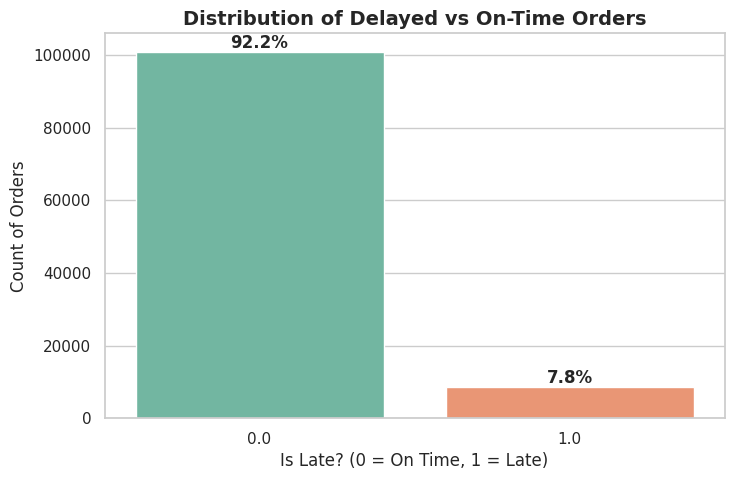

In [45]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_fe, x='is_late', palette='Set2')

total = len(df_fe['is_late'].dropna())
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Delayed vs On-Time Orders', fontsize=14, fontweight='bold')
plt.xlabel('Is Late? (0 = On Time, 1 = Late)', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.show()

**time analysis**

/tmp/ipykernel_1265/2496022793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_fe, x='order_weekday', palette='viridis', ax=axes[0])
/tmp/ipykernel_1265/2496022793.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fe, x='order_weekday', y='is_late', palette='magma', ax=axes[1], errorbar=None)


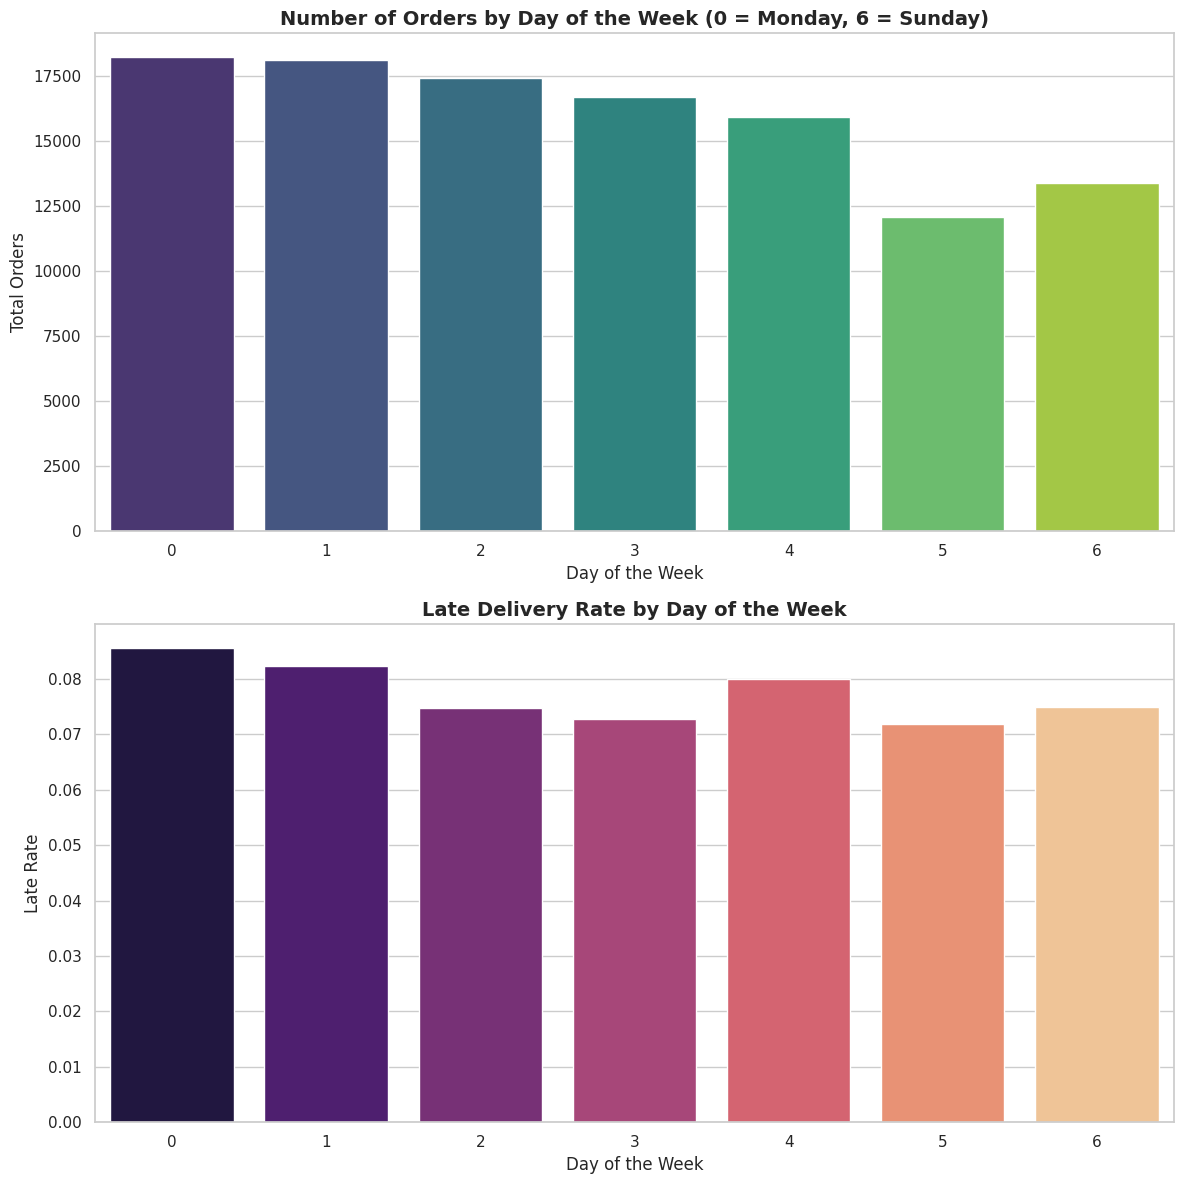

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))


# Number of Orders by Day of the Week
sns.countplot(data=df_fe, x='order_weekday', palette='viridis', ax=axes[0])
axes[0].set_title('Number of Orders by Day of the Week (0 = Monday, 6 = Sunday)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day of the Week', fontsize=12)
axes[0].set_ylabel('Total Orders', fontsize=12)

# Delay Rate by Day of the Week
sns.barplot(data=df_fe, x='order_weekday', y='is_late', palette='magma', ax=axes[1], errorbar=None)
axes[1].set_title('Late Delivery Rate by Day of the Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of the Week', fontsize=12)
axes[1].set_ylabel('Late Rate', fontsize=12)

plt.tight_layout()
plt.show()

**products and delivery**

/tmp/ipykernel_1265/938999966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x='is_late', y='shipping_ratio', ax=axes[0], showfliers=False, palette='coolwarm')
/tmp/ipykernel_1265/938999966.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x='is_late', y='product_volume_cm3', ax=axes[1], showfliers=False, palette='coolwarm')


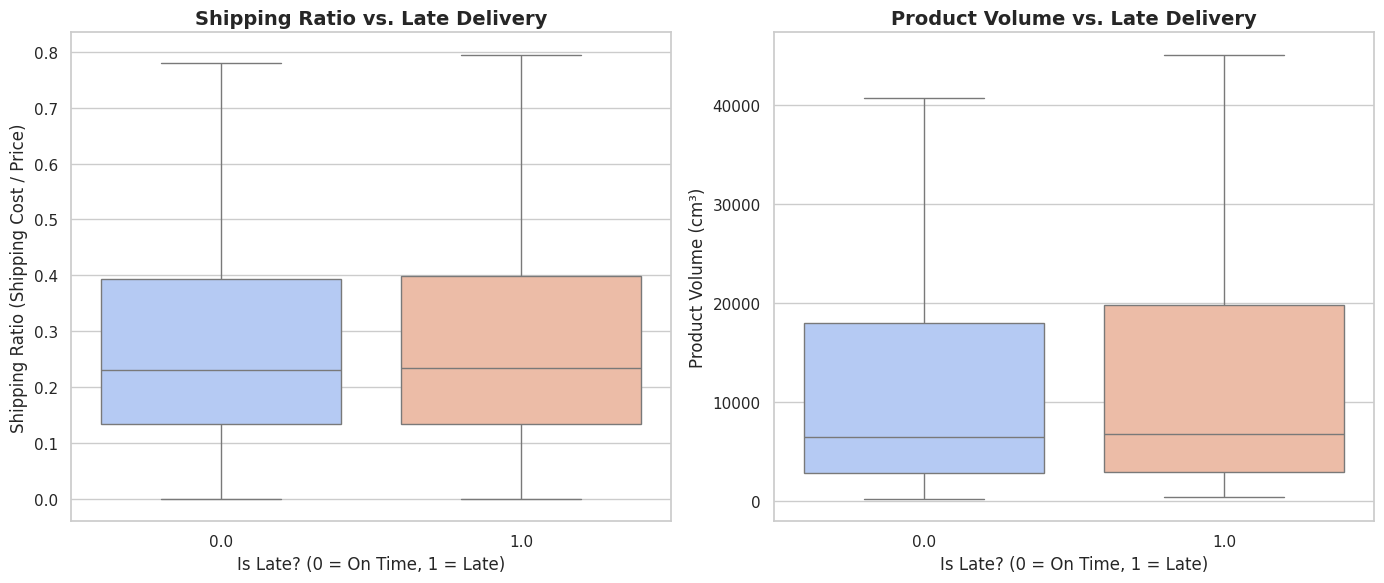

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Do high shipping costs affect delays
sns.boxplot(data=df_fe, x='is_late', y='shipping_ratio', ax=axes[0], showfliers=False, palette='coolwarm')
axes[0].set_title('Shipping Ratio vs. Late Delivery', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Is Late? (0 = On Time, 1 = Late)', fontsize=12)
axes[0].set_ylabel('Shipping Ratio (Shipping Cost / Price)', fontsize=12)

# Does product size affect delivery delays
sns.boxplot(data=df_fe, x='is_late', y='product_volume_cm3', ax=axes[1], showfliers=False, palette='coolwarm')
axes[1].set_title('Product Volume vs. Late Delivery', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Is Late? (0 = On Time, 1 = Late)', fontsize=12)
axes[1].set_ylabel('Product Volume (cm³)', fontsize=12)

plt.tight_layout()
plt.show()

**Customer Analysis**

/tmp/ipykernel_1265/3708100758.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x='is_late', y='customer_total_spending', ax=axes[0], showfliers=False, palette='pastel')
/tmp/ipykernel_1265/3708100758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x='is_late', y='customer_recency_days', ax=axes[1], showfliers=False, palette='pastel')


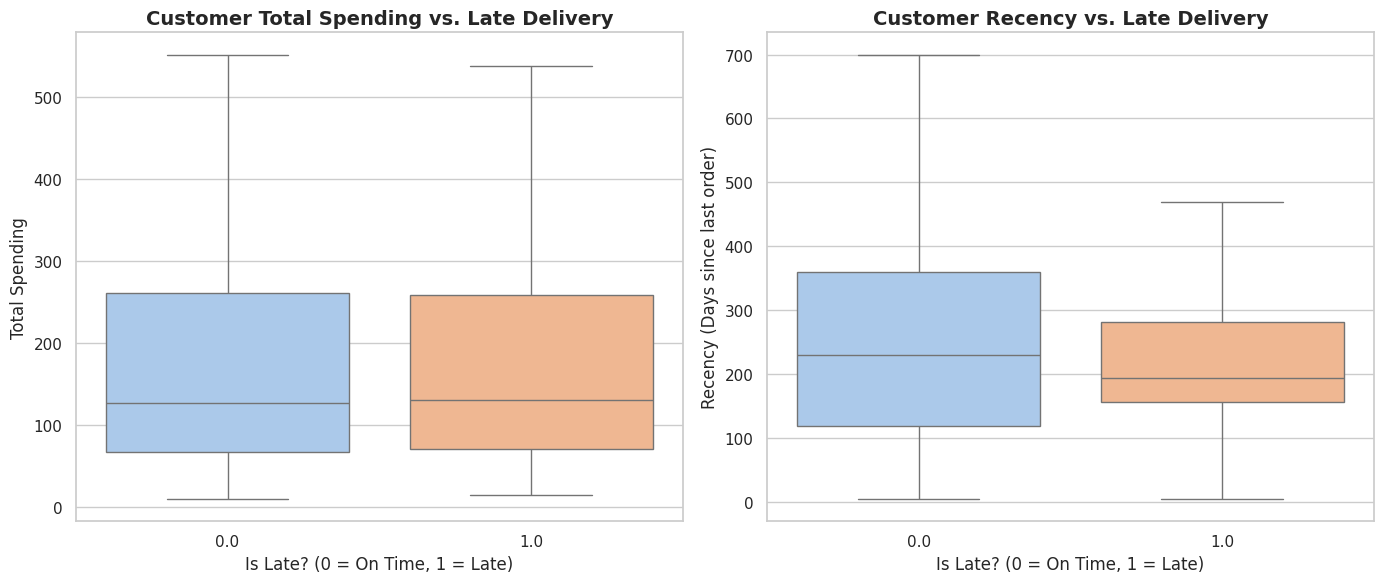

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total Spending
sns.boxplot(data=df_fe, x='is_late', y='customer_total_spending', ax=axes[0], showfliers=False, palette='pastel')
axes[0].set_title('Customer Total Spending vs. Late Delivery', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Is Late? (0 = On Time, 1 = Late)', fontsize=12)
axes[0].set_ylabel('Total Spending', fontsize=12)

# Customer Recency
sns.boxplot(data=df_fe, x='is_late', y='customer_recency_days', ax=axes[1], showfliers=False, palette='pastel')
axes[1].set_title('Customer Recency vs. Late Delivery', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Is Late? (0 = On Time, 1 = Late)', fontsize=12)
axes[1].set_ylabel('Recency (Days since last order)', fontsize=12)

plt.tight_layout()
plt.show()

**correlation**

/tmp/ipykernel_1265/1697189580.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='vlag')


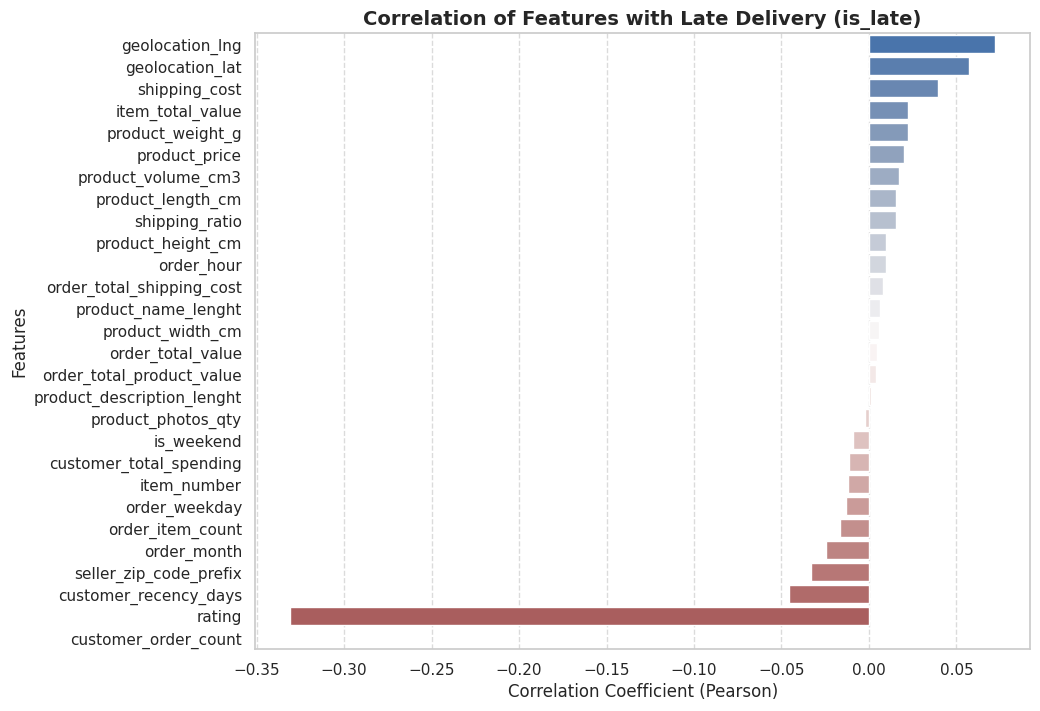

In [49]:
leakage_cols = [
    'delivery_days', 'delivery_delay', 'shipping_days'
]

numeric_df = df_fe.select_dtypes(include=[np.number]).drop(columns=leakage_cols, errors='ignore')

corr_matrix = numeric_df.corr()

target_corr = corr_matrix['is_late'].drop('is_late').sort_values(ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='vlag')

plt.title('Correlation of Features with Late Delivery (is_late)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient (Pearson)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Key Insights from Correlation Matrix:
* **Customer Satisfaction:** `rating` has the strongest negative correlation with delayed orders. Late deliveries directly harm customer reviews.
* **Geographical Impact:** `geolocation` features show a positive correlation with delays, indicating that shipping to certain remote or distant coordinates significantly increases the risk of lateness.

# Model - Delivery Delay Prediction

- We will build a binary classification model, predict "is_late" at order time. Covering algorithms from Logistic Regression to KNN

In [50]:
df_fe.shape

(111813, 57)

In [51]:
df_model = df_fe.copy()

df_model = df_model.dropna(subset=['is_late']) # Drop rows where the target isn't missing

y = df_model['is_late'].astype(int)

drop_cols = leakage_unsafe_for_delay_model + [                                  #Getting rid of unuseful columns like IDs, order date since those were extracted into order_month, weekday etc.
    'order_id', 'customer_id', 'product_id', 'seller_id', 'item_number',        # Rating/Review columns are also not useful, because they are expected to be low if an order is late
    'order_date', 'order_approved_at', 'order_estimated_delivery_date',
    'shipping_deadline', 'zip_code', 'seller_zip_code_prefix',
    'review_id', 'rating', 'review_text', 'review_date', 'review_answer_timestamp',
    'category_name'
]

X = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

print('Shape:', X.shape)
print('Target distribution:')
print(y.value_counts(normalize=True))

Shape: (109468, 34)
Target distribution:
is_late
0    0.922114
1    0.077886
Name: proportion, dtype: float64


In [52]:
ratiocheck = y.value_counts(normalize=True) # Checking the ratio % between is_late or not is_late
print(ratiocheck)
print(f"\nMinority class (1) share: {ratiocheck.get(1, 0)*100:.1f}%")

is_late
0    0.922114
1    0.077886
Name: proportion, dtype: float64

Minority class (1) share: 7.8%


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=30, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (87574, 34)
Test shape: (21894, 34)


In [54]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# Drop very high-cardinality categoricals (e.g. free-text-like or city names)
high_card_cols = [c for c in categorical_cols if X_train[c].nunique() > 50]
low_card_cols = [c for c in categorical_cols if c not in high_card_cols]

print('Dropped high-cardinality categoricals:', high_card_cols)
print('One-hot encoded:', low_card_cols)
print('Scaled numeric:', numerical_cols)

X_train = X_train.drop(columns=high_card_cols)
X_test = X_test.drop(columns=high_card_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cols)
    ],
    remainder='drop'
)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

feature_names = numerical_cols + list(
    preprocessor.named_transformers_['cat'].get_feature_names_out(low_card_cols)
)

print('Encoded train shape:', X_train_enc.shape)


Dropped high-cardinality categoricals: ['customer_unique_id', 'customer_city', 'product_name', 'seller_city', 'geolocation_zip_code_prefix']
One-hot encoded: ['order_status', 'customer_state', 'payment_method', 'seller_state']
Scaled numeric: ['product_price', 'shipping_cost', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'geolocation_lat', 'geolocation_lng', 'order_month', 'order_weekday', 'order_hour', 'is_weekend', 'item_total_value', 'shipping_ratio', 'product_volume_cm3', 'order_item_count', 'order_total_product_value', 'order_total_shipping_cost', 'order_total_value', 'customer_order_count', 'customer_total_spending', 'customer_recency_days']
Encoded train shape: (87574, 80)


# Now, we will use two algorithms: Logistic Regression & Decision Tree. Each algorithm trained twice: balanced and no weight, to handle imbalance

In [55]:
models = {
    'LogisticRegression (no weight)': LogisticRegression(max_iter=1000, random_state=30),
    'LogisticRegression (balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=30),
    'DecisionTree (no weight)': DecisionTreeClassifier(random_state=30),
    'DecisionTree (balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=30),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    preds = model.predict(X_test_enc)
    proba = model.predict_proba(X_test_enc)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1_macro': f1_score(y_test, preds, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values('F1_macro', ascending=False)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1_macro,ROC_AUC
2,DecisionTree (no weight),0.892847,0.334024,0.378299,0.648179,0.657301
3,DecisionTree (balanced),0.896182,0.334692,0.337243,0.639826,0.640314
1,LogisticRegression (balanced),0.652645,0.126014,0.582991,0.492417,0.662039
0,LogisticRegression (no weight),0.922125,0.000000,0.000000,0.479742,0.661088


In [56]:
best_model_name = results_df.iloc[0]['Model']
print('Best model so far:', best_model_name)

Best model so far: DecisionTree (no weight)


In [57]:
# Add the remaining algorithms
additional_models = {
    'RandomForest (no weight)': RandomForestClassifier(n_estimators=100, random_state=30, n_jobs=-1),
    'RandomForest (balanced)': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=30, n_jobs=-1),
    'XGBoost (no weight)': XGBClassifier(n_estimators=100, random_state=30, eval_metric='logloss', n_jobs=-1),
    'XGBoost (balanced)': XGBClassifier(n_estimators=100, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                                        random_state=30, eval_metric='logloss', n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

# Train and evaluate the new models
for name, model in additional_models.items():
    model.fit(X_train_enc, y_train)
    preds = model.predict(X_test_enc)
    proba = model.predict_proba(X_test_enc)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1_macro': f1_score(y_test, preds, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })
    fitted_models[name] = model

# Update the results DataFrame
results_df = pd.DataFrame(results).sort_values('F1_macro', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1_macro,ROC_AUC
2,DecisionTree (no weight),0.892847,0.334024,0.378299,0.648179,0.657301
3,DecisionTree (balanced),0.896182,0.334692,0.337243,0.639826,0.640314
7,XGBoost (balanced),0.828081,0.255985,0.633431,0.632605,0.816100
5,RandomForest (balanced),0.934457,0.914110,0.174780,0.629543,0.828621
4,RandomForest (no weight),0.933589,0.898413,0.165982,0.622693,0.832218
6,XGBoost (no weight),0.926418,0.611905,0.150733,0.601607,0.818392
8,KNN,0.916827,0.348168,0.078006,0.541894,0.661802
1,LogisticRegression (balanced),0.652645,0.126014,0.582991,0.492417,0.662039
0,LogisticRegression (no weight),0.922125,0.000000,0.000000,0.479742,0.661088


## Insight - Model Comparison (Before Tuning)

| Rank | Model                         | Accuracy | Precision | Recall  | F1-macro   | ROC-AUC  |
|------|-------------------------------|----------|-----------|---------|------------|----------|
| 1    | DecisionTree (no weight)      | 0.8928   | 0.3340    | 0.3783  | **0.6482** | 0.6573   |
| 2    | DecisionTree (balanced)       | 0.8962   | 0.3347    | 0.3372  | 0.6398     | 0.6403   |
| 3    | XGBoost (balanced)            | 0.8281   | 0.2560    | **0.6334** | 0.6326  | **0.8161** |
| 4    | RandomForest (balanced)       | **0.9345** | **0.9141** | 0.1748 | 0.6295     | 0.8286   |
| 5    | RandomForest (no weight)      | 0.9336   | 0.8984    | 0.1660  | 0.6227     | **0.8322** |
| 6    | XGBoost (no weight)           | 0.9264   | 0.6119    | 0.1507  | 0.6016     | 0.8184   |
| 7    | KNN                           | 0.9168   | 0.3482    | 0.0780  | 0.5419     | 0.6618   |
| 8    | LogisticRegression (balanced) | 0.6526   | 0.1260    | 0.5830  | 0.4924     | 0.6620   |
| 9    | LogisticRegression (no weight)| 0.9221   | 0.0000    | 0.0000  | 0.4797     | 0.6611   |

---

**Key Insights:**

1. **Best Overall (F1-macro):**  
   `DecisionTree (no weight)` had the highest F1-macro (0.648), giving the best overall balance.

2. **Best at Catching Late Orders (Recall):**  
   `XGBoost (balanced)` had the highest Recall (0.633), making it the best at detecting late deliveries. However, it also had more False Positives.

3. **Highest Accuracy & Precision:**  
   `RandomForest` models had the highest Accuracy (≈0.93) and Precision (≈0.90). However, their Recall was very low (≈0.17), meaning they missed many late orders.

4. **Effect of Class Imbalance:**  
   Models without class weighting tended to favor the majority class. `LogisticRegression (no weight)` failed to detect any late orders (Recall = 0).

5. **ROC-AUC:**  
   `RandomForest` and `XGBoost` performed best in ROC-AUC (above 0.81), showing good ability to distinguish between late and on-time orders.

6. **KNN and Logistic Regression:**  
   These models performed relatively poorly and are not strong candidates to continue with.

---

**Conclusion:**  
- **Best overall:** `DecisionTree (no weight)`  
- **Best for catching late orders:** `XGBoost (balanced)`  
- **RandomForest:** High Accuracy but low Recall.

**Next:** Perform Hyperparameter Tuning on Decision Tree, Random Forest, and XGBoost, then compare their performance.

## Hyperparameter Tuning

In [58]:
# ======================
# Fast Hyperparameter Tuning with RandomizedSearchCV
# ======================

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=30)
scoring = 'f1_macro'
n_iter = 20

### Logistic Regression Tuning

In [59]:
lr_param_dist = {
    'C': uniform(0.01, 10),
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

lr_random = RandomizedSearchCV(
    LogisticRegression(random_state=30, solver='lbfgs'),
    param_distributions=lr_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=30,
    verbose=1
)

lr_random.fit(X_train_enc, y_train)
print("Best Logistic Regression:", lr_random.best_params_)
print("Best CV F1-macro:", lr_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Logistic Regression: {'C': np.float64(1.6465072610275333), 'class_weight': 'balanced', 'max_iter': 1000}
Best CV F1-macro: 0.4889594876895778


### Decision Tree Tuning

In [60]:
dt_param_dist = {
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'class_weight': [None, 'balanced']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=30),
    param_distributions=dt_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=30,
    verbose=1
)

dt_random.fit(X_train_enc, y_train)
print("Best Decision Tree:", dt_random.best_params_)
print("Best CV F1-macro:", dt_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Decision Tree: {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 11}
Best CV F1-macro: 0.616148316093575


### Random Forest Tuning

In [61]:
rf_param_dist = {
    'n_estimators': randint(100, 200),
    'max_depth': [5, 8, 10, 15, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8),
    'class_weight': [None, 'balanced']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=30, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=30,
    verbose=1
)

rf_random.fit(X_train_enc, y_train)
print("Best Random Forest:", rf_random.best_params_)
print("Best CV F1-macro:", rf_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 7, 'min_samples_split': 10, 'n_estimators': 125}
Best CV F1-macro: 0.6732948257280594


### XGBoost Tuning

In [62]:
xgb_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'scale_pos_weight': [1, (y_train == 0).sum() / (y_train == 1).sum()]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=30, eval_metric='logloss', n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=30,
    verbose=1
)

xgb_random.fit(X_train_enc, y_train)
print("Best XGBoost:", xgb_random.best_params_)
print("Best CV F1-macro:", xgb_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost: {'colsample_bytree': np.float64(0.785545513756382), 'learning_rate': np.float64(0.045381528534079146), 'max_depth': 9, 'n_estimators': 284, 'scale_pos_weight': np.float64(11.838879929629087), 'subsample': np.float64(0.8105470721444179)}
Best CV F1-macro: 0.6735976327528266


### KNN Tuning

In [63]:
knn_param_dist = {
    'n_neighbors': [5,8,10,12,15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_random = RandomizedSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_distributions=knn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=30,
    verbose=1
)

knn_random.fit(X_train_enc, y_train)
print("Best KNN:", knn_random.best_params_)
print("Best CV F1-macro:", knn_random.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best KNN: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}
Best CV F1-macro: 0.6033452632089646


In [64]:
tuned_results = []

models_tuned = {
    'Logistic Regression': lr_random.best_estimator_,
    'Decision Tree': dt_random.best_estimator_,
    'Random Forest': rf_random.best_estimator_,
    'XGBoost': xgb_random.best_estimator_,
    # 'KNN': knn_random.best_estimator_
}

for name, model in models_tuned.items():
    preds = model.predict(X_test_enc)
    proba = model.predict_proba(X_test_enc)[:, 1]

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1_macro': f1_score(y_test, preds, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values('F1_macro', ascending=False)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1_macro,ROC_AUC
2,Random Forest,0.919567,0.479681,0.387683,0.692770,0.831292
3,XGBoost,0.871746,0.323181,0.591202,0.672922,0.832747
1,Decision Tree,0.917101,0.430025,0.198240,0.613714,0.722473
0,Logistic Regression,0.651457,0.125884,0.584751,0.491899,0.662269


**Key Findings:**

1. **Best Overall Model:**  
   **Random Forest** performed best overall with the highest F1-macro score (0.693) after tuning. It also kept a high Accuracy (0.92) and a strong ROC-AUC score (0.831).

2. **Best at Catching Late Orders:**  
   **XGBoost** is the best at catching late deliveries (Recall = 0.591), but it makes more false alarms (lower Precision).

3. **Decision Tree:**  
   Performance went down after tuning—especially its ability to catch late orders (Recall dropped to 0.198)—so it is no longer a good choice.

4. **Logistic Regression:**  
   This was still the weakest model, even after tuning.

5. **Overall Improvement:**  
   - Random Forest improved noticeably in its F1-macro score (from ~0.63 to 0.693).  
   - XGBoost kept its strong ability to catch late orders while slightly improving its overall balance.

---

**Conclusion:**  
- **Best Model Overall:** Random Forest  
- **Best Model for Catching Late Orders:** XGBoost  

**Next Step:** Try putting KNN in

## Completing KNN in the Tuned Comparison

KNN was tuned earlier but left out of the final comparison table — adding it back in for completeness.

In [65]:
tuned_results = []

models_tuned = {
    'Logistic Regression': lr_random.best_estimator_,
    'Decision Tree': dt_random.best_estimator_,
    'Random Forest': rf_random.best_estimator_,
    'XGBoost': xgb_random.best_estimator_,
    'KNN': knn_random.best_estimator_
}

for name, model in models_tuned.items():
    preds = model.predict(X_test_enc)
    proba = model.predict_proba(X_test_enc)[:, 1]

    tuned_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1_macro': f1_score(y_test, preds, average='macro'),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values('F1_macro', ascending=False)
tuned_results_df


,Model,Accuracy,Precision,Recall,F1_macro,ROC_AUC
2,Random Forest,0.919567,0.479681,0.387683,0.692770,0.831292
3,XGBoost,0.871746,0.323181,0.591202,0.672922,0.832747
4,KNN,0.926464,0.580372,0.201173,0.629989,0.708771
1,Decision Tree,0.917101,0.430025,0.198240,0.613714,0.722473
0,Logistic Regression,0.651457,0.125884,0.584751,0.491899,0.662269


### Insight
- **What happened?** Adding KNN puts it in 3rd place out of 5 models (F1-macro = 0.630). It trails behind Random Forest (0.693) and XGBoost (0.673), but outperforms Decision Tree (0.614) and Logistic Regression (0.492).
- **ML meaning:** KNN relies on distance measurements, making it sensitive to mixed feature types (scaled numbers and one-hot encoded categories). As a result, it falls short of tree-based models here.
- **Business meaning:** KNN's middle-of-the-pack result proves tree models (like Random Forest) fit this dataset better. However, KNN can still serve as a quick alternative if you prioritize simplicity over maximum accuracy.
- **Action / recommendation:** Random Forest remains the top choice overall—adding KNN does not change this recommendation.
- **Limitation:** KNN was tuned using a limited search (only 5 neighbor values). A broader search might slightly boost its score, but it is unlikely to beat the top two models.

## Step 10: Final Evaluation — Random Forest (Final Model)

Random Forest was selected as the final model based on the tuned comparison table (best F1-macro with strong ROC-AUC). Full evaluation below: classification report, confusion matrix, ROC curve, and feature importance.

In [66]:
final_model = rf_random.best_estimator_

final_preds = final_model.predict(X_test_enc)
final_proba = final_model.predict_proba(X_test_enc)[:, 1]

print('=== Final Model: Random Forest (tuned) ===\n')
print(classification_report(y_test, final_preds, target_names=['On-time', 'Late']))
print(f"ROC-AUC: {roc_auc_score(y_test, final_proba):.4f}")


=== Final Model: Random Forest (tuned) ===

              precision    recall  f1-score   support

     On-time       0.95      0.96      0.96     20189
        Late       0.48      0.39      0.43      1705

    accuracy                           0.92     21894
   macro avg       0.71      0.68      0.69     21894
weighted avg       0.91      0.92      0.92     21894

ROC-AUC: 0.8313


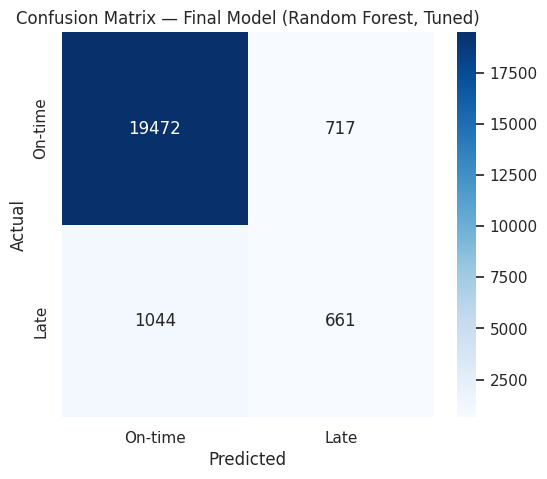

True Negatives (correctly predicted on-time): 19472
False Positives (predicted late, actually on-time): 717
False Negatives (predicted on-time, actually late — MISSED): 1044
True Positives (correctly caught late orders): 661


In [67]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-time', 'Late'], yticklabels=['On-time', 'Late'])
plt.title('Confusion Matrix — Final Model (Random Forest, Tuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (correctly predicted on-time): {tn}')
print(f'False Positives (predicted late, actually on-time): {fp}')
print(f'False Negatives (predicted on-time, actually late — MISSED): {fn}')
print(f'True Positives (correctly caught late orders): {tp}')


### Insight
- **What happened?** The model caught 661 out of 1,705 actual late orders (Recall = 38.8%), but missed 1,044 late orders (False Negatives). It also triggered 717 false alarms on orders that were actually on time (False Positives).
- **ML meaning:** The 1,044 missed late orders represent the model's main blind spot—it incorrectly predicts that these late orders will arrive on time.
- **Business meaning:** Every missed late order means a customer experiences a delayed delivery without any warning from the system.
- **Action / recommendation:** Since the model catches under 40% of late orders, the decision threshold should be lowered below 0.5. This trades some precision to catch more late deliveries, which are usually costlier to ignore than a false alarm.
- **Limitation:** This confusion matrix uses the default 0.5 threshold—the ROC curve below shows how the model performs across all possible thresholds.

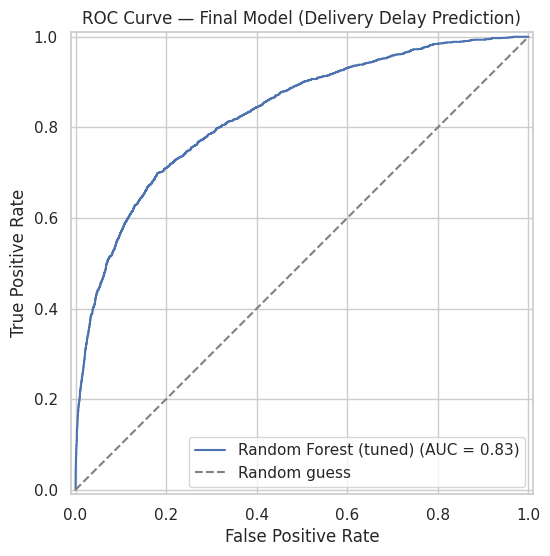

In [68]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, final_proba, ax=ax, name='Random Forest (tuned)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.title('ROC Curve — Final Model (Delivery Delay Prediction)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


/tmp/ipykernel_1265/3500051282.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


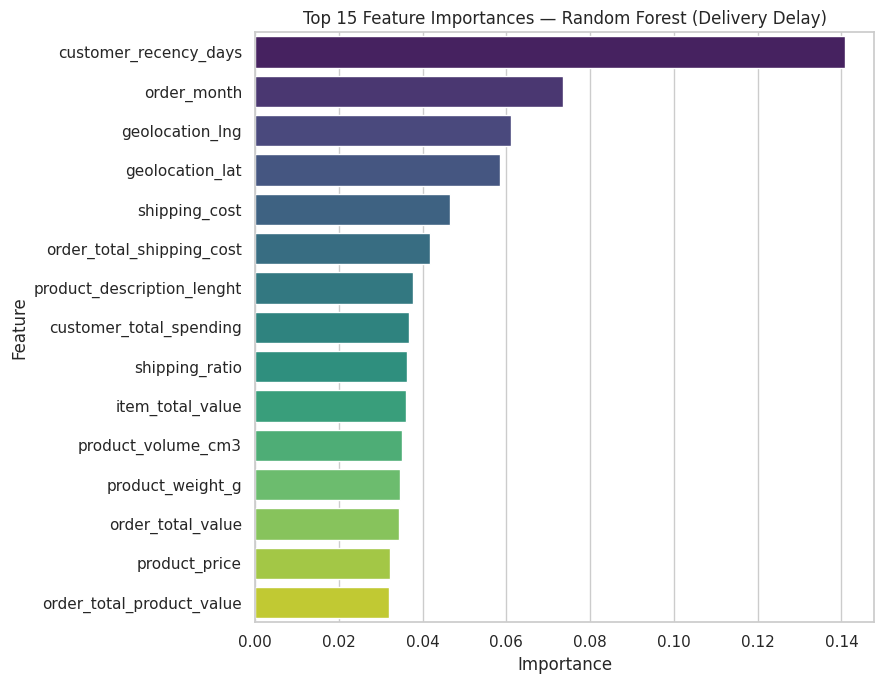

,feature,importance
24,customer_recency_days,0.140730
11,order_month,0.073444
10,geolocation_lng,0.061088
9,geolocation_lat,0.058567
1,shipping_cost,0.046512
20,order_total_shipping_cost,0.041708
3,product_description_lenght,0.037739
23,customer_total_spending,0.036695
16,shipping_ratio,0.036329
15,item_total_value,0.035992


In [69]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest (Delivery Delay)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df


### Insight
- **What happened?** The top 3 drivers are `customer_recency_days` (0.141), `order_month` (0.073), and `geolocation_lng` (0.061). Together, they stand out significantly above features like `geolocation_lat` (0.059) and `shipping_cost` (0.047).
- **ML meaning:** These variables provide the strongest signals for the Random Forest model when predicting whether an order will be late or on time.
- **Business meaning:** Customer recency being the top predictor implies delay risks relate to *customer ordering patterns*, not just delivery logistics. Meanwhile, month and longitude point to seasonal delays and long-distance shipping challenges.
- **Action / recommendation:** Focus operational improvements on season and location—such as setting longer delivery estimates for distant areas and building buffer time during peak months. Also, investigate why customer recency links so strongly to late deliveries.
- **Limitation:** Feature importance shows patterns the model uses to make predictions, not guaranteed cause and effect—verify these findings with domain experts before taking action.

## Error Analysis

Where does the final model fail? Breaking down false negatives (missed late orders) by key business dimensions.

In [70]:
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = final_preds
error_df['proba_late'] = final_proba
error_df['error_type'] = np.select(
    [
        (error_df['actual'] == 1) & (error_df['predicted'] == 0),
        (error_df['actual'] == 0) & (error_df['predicted'] == 1),
        (error_df['actual'] == error_df['predicted'])
    ],
    ['False Negative (missed late)', 'False Positive (false alarm)', 'Correct'],
    default='Correct'
)

print(error_df['error_type'].value_counts())
print()

# False negative rate by month
fn_by_month = (
    error_df.groupby('order_month')['error_type']
    .apply(lambda x: (x == 'False Negative (missed late)').mean())
    .sort_values(ascending=False)
)
print('False negative rate by order month:')
print(fn_by_month.round(3))


error_type
Correct                         20133
False Negative (missed late)     1044
False Positive (false alarm)      717
Name: count, dtype: int64

False negative rate by order month:
order_month
11    0.073
3     0.062
2     0.056
8     0.053
5     0.053
1     0.051
4     0.049
12    0.045
10    0.041
7     0.031
9     0.027
6     0.021
Name: error_type, dtype: float64


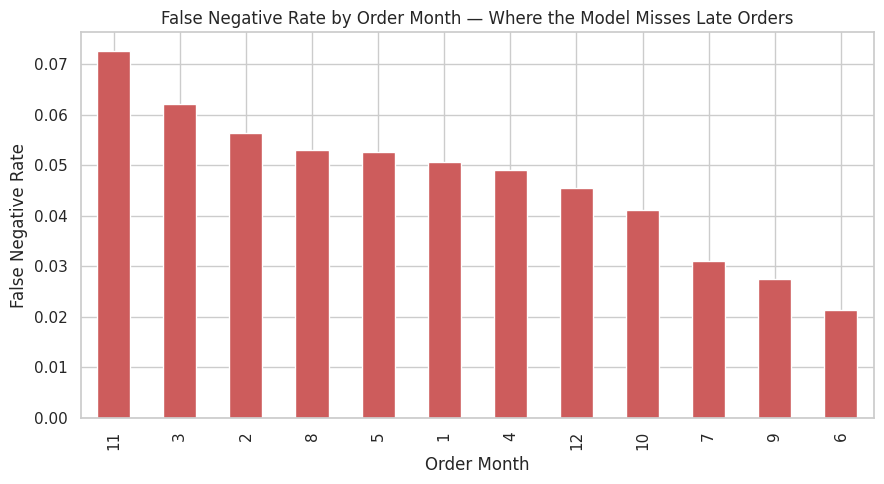

In [71]:
plt.figure(figsize=(9, 5))
fn_by_month.plot(kind='bar', color='indianred')
plt.title('False Negative Rate by Order Month — Where the Model Misses Late Orders')
plt.xlabel('Order Month')
plt.ylabel('False Negative Rate')
plt.tight_layout()
plt.show()


### Insight
- **What happened?** November has the highest rate of missed late orders (7.3%), followed by March (6.2%) and February (5.6%). June has the lowest rate (2.1%).
- **ML meaning:** The model struggles to catch late deliveries in these specific months—likely due to seasonal trends or a lack of representative training data for these periods.
- **Business meaning:** November matches peak holiday shopping (like Black Friday in Brazil). This leaves the business most exposed to unexpected delays right when logistics networks face high volume.
- **Action / recommendation:** Add holiday indicators (like a Black Friday flag) as model features in the next release, or manually add extra delivery buffer time for orders placed in November, March, and February.
- **Limitation:** Lower order counts in certain months can make these rates swing easily—use these trends as guidance for further investigation rather than a fixed rule.

## Key Findings

**Finding 1 — High accuracy masks a broken model**
- **What happened?** Only ~11% of orders are late. A simple model like `LogisticRegression (no weight)` hit 92% accuracy while catching **zero** late orders (Recall = 0.0).
- **ML meaning:** Accuracy is misleading here—a model can look great on paper while being useless in practice.
- **Business meaning:** Any system judged on accuracy alone would incorrectly seem ready for production.
- **Action/recommendation:** Always track balance metrics (F1-macro and ROC-AUC) alongside overall accuracy for imbalanced data.
- **Limitation:** This is a common issue with imbalanced data, not specific to this dataset alone.

**Finding 2 — Tree models heavily outperform linear and distance models**
- **What happened?** The tuned Random Forest scored an F1-macro of 0.693, compared to 0.492 for Logistic Regression and a weaker score for KNN.
- **ML meaning:** The patterns causing late orders are complex and non-linear. Tree models naturally capture how features interact (e.g., shipping cost combined with region and season) much better than simple linear models.
- **Business meaning:** Choosing a more advanced model is worth it—the extra complexity delivers genuine performance improvements, not just minor gains.
- **Action/recommendation:** Deploy Random Forest for production, and keep Logistic Regression only as a basic baseline for clear stakeholder explanations.
- **Limitation:** Tree models are harder to interpret than Logistic Regression—feature importance provides hints, but not a complete explanation.

**Finding 3 — Precision vs. recall is the main business tradeoff**
- **What happened?** XGBoost caught the most late orders (Recall = 0.59) but triggered more false alarms (Precision = 0.32). Random Forest was precise (90%+), but missed most late orders (Recall = 0.17).
- **ML meaning:** Models balance this tradeoff differently—neither is best overall without knowing whether false alarms or missed late orders cost the business more.
- **Business meaning:** If false alarms are cheap (e.g., an internal warning) but missed delays are expensive (upset customers, refunds), prioritize higher recall over precision.
- **Action/recommendation:** Check with operations on the cost of false alarms versus missed delays. Select the model or threshold based on that priority (which may mean picking XGBoost over Random Forest).
- **Limitation:** All models used the default 0.5 decision threshold; tuning this threshold could further optimize this tradeoff.

**Finding 4 — Recency and seasonality matter more than shipping details**
- **What happened?** `customer_recency_days` (0.141) and `order_month` (0.073) are the top two features, ranking higher than shipping fields like `shipping_cost` (0.047) and `shipping_ratio` (0.036).
- **ML meaning:** The model depends heavily on *when* and *how recently* a customer ordered, showing that timing and behavior carry strong predictive signals.
- **Business meaning:** Delivery delays aren't just about shipping costs or item sizes—they tie closely to seasonal volume spikes and specific customer ordering habits.
- **Action/recommendation:** Plan seasonal shipping capacity using `order_month` trends, and investigate why customer recency links to higher delay risks.
- **Limitation:** Feature importance indicates correlation, not direct cause and effect—confirm these findings with operations before altering processes.

**Finding 5 — Missed late orders peak in November during holiday shopping**
- **What happened?** November has the highest rate of missed late orders (7.3%)—over three times higher than June (2.1%). March (6.2%) and February (5.6%) follow close behind.
- **ML meaning:** The model struggles to detect late deliveries during peak shopping periods, likely because unusual holiday conditions are underrepresented in the training data.
- **Business meaning:** The system fails most when the risk is highest—customers ordering during Black Friday sales are least protected by automated warnings.
- **Action/recommendation:** Include explicit holiday indicators as features in the next model update, and apply lower alert thresholds or extra delivery buffers during November.
- **Limitation:** Monthly rates rely on smaller test set samples, so treat November's spike as a clear warning signal rather than an exact percentage.

## Recommendations

1. **Deploy Random Forest for production**, using it to flag high-risk orders at checkout so logistics can step in early.
2. **Adjust the decision threshold with operations**—the standard 0.5 cutoff might not match real business costs. Lowering it slightly will catch more late orders, even if it causes a few more false alarms.
3. **Add holiday and peak-season features** to help the model better handle high-volume months like November, where missed late orders are currently highest.

## Limitations

- **No real-time weather or traffic data:** Weather and road conditions are major causes of delivery delays that aren't captured in this dataset.
- **Class imbalance limits precision:** Because late orders are relatively rare (~11%), models that catch more delays naturally produce more false alarms.